In [2]:
import numpy as np
import random
from dataclasses import dataclass 
import matplotlib.pyplot as plt

In [80]:
@dataclass
class KArmBanditsConfig:
    k: int
    max_reward: float = 3.0
    min_reward: float = -3.0
    reward_std: float = 1.0
    epsilon: float = 0.0

        
class Bandit:
    def __init__(self, reward, reward_std):
        self.true_reward = reward
        self.reward_std = reward_std
    
    def get_reward(self):
        return random.gauss(self.true_reward, self.reward_std)


def initialize_bandits(config: KArmBanditsConfig):
    bandits = []
    for i in range(config.k):
        bandit = Bandit(
            random.uniform(config.min_reward, config.max_reward),
            config.reward_std
        )
        bandits.append(bandit)
    return bandits    
    

class KArmBandits:
    def __init__(self, config: KArmBanditsConfig, bandits):
        self.k = config.k
        self.epsilon = config.epsilon
        self.bandits = bandits
        
        self.q_estimates = [0.0 for _ in range(self.k)]
        self.action_counter = [0 for _ in range(self.k)]
        
        self.optimal_action = np.argmax([b.true_reward for b in bandits])
        
    def choose_action(self):
        if random.random() < self.epsilon:
            return random.choice(range(self.k))
        
        # need to randomly choose among the tied best actions.
        max_q = max(self.q_estimates)
        best_actions = [
            i for i, q in enumerate(self.q_estimates)
            if q == max_q
        ]
        return random.choice(best_actions)
        
    def estimate(self, action, reward):
        self.action_counter[action] += 1
        n = self.action_counter[action]
        prev = self.q_estimates[action]
        self.q_estimates[action] += (reward - prev) / n
    
    def play(self, steps: int = 1000):
        avg_reward = []
        acc_reward = 0
        optimal_action_ratio = []
        optimal_action_count = 0
        for i in range(steps):
            action = self.choose_action()
            r = self.bandits[action].get_reward()
            self.estimate(action, r)
            acc_reward += r
            avg_reward.append(acc_reward / (i + 1))
            
            optimal_action_count += (action == self.optimal_action)
            optimal_action_ratio.append(optimal_action_count / (i + 1))
            
        return avg_reward, optimal_action_ratio

    def reset(self):
        self.q_estimates = [0.0 for _ in range(self.k)]
        self.action_counter = [0 for _ in range(self.k)]

In [81]:
def run_experiments(epsilon, config, bandits, steps=1000, nums=200):
    config.epsilon = epsilon
    karm_bandits = KArmBandits(config, bandits)
    reward_result = []
    optimal_ratio_result = []
    for _ in range(nums):
        karm_bandits.reset()
        avg_reward, optimal_ratio = karm_bandits.play(steps)
        reward_result.append(avg_reward)
        optimal_ratio_result.append(optimal_ratio)
    
    return np.array(reward_result), np.array(optimal_ratio_result)

In [82]:
config = KArmBanditsConfig(k=10, max_reward=3, min_reward=-3, reward_std=1.0)
bandits = initialize_bandits(config)

In [85]:
eps = [0, 0.01, 0.1, 0.3, 0.5]
reward = {}
optimal_ratio = {}
for e in eps:
    r, o = run_experiments(e, config, bandits, 1000, 2000)
    reward[e] = np.mean(r, axis=0)
    optimal_ratio[e] = np.mean(o, axis=0)

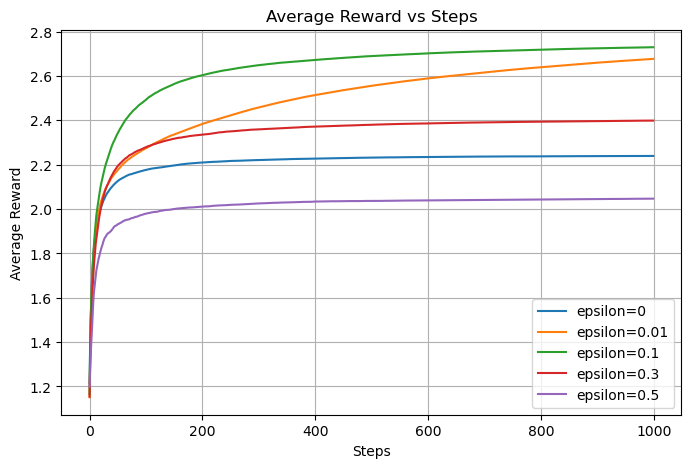

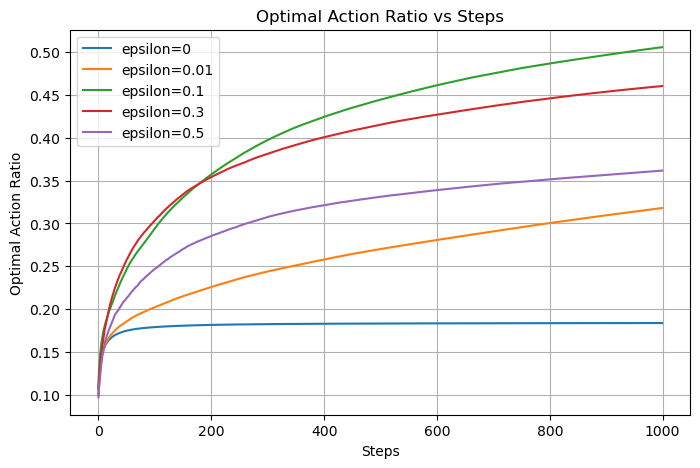

In [86]:
# Plot average reward
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(reward[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot optimal action ratio
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(optimal_ratio[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Optimal Action Ratio")
plt.title("Optimal Action Ratio vs Steps")
plt.legend()
plt.grid(True)
plt.show()